In [1]:
import pandas as pd
import numpy as np
import joblib

from math import radians, sin, cos, sqrt, atan2
from sklearn.preprocessing import StandardScaler

df = pd.read_csv(r"C:\Users\SAMIKSHA\Desktop\Factory-Reallocation-Optimization\data\ml_ready_data.csv")

model = joblib.load(r"C:\Users\SAMIKSHA\Desktop\Factory-Reallocation-Optimization\models\gradient_boosting.pkl")

In [2]:
factory_encoder = joblib.load(r"C:\Users\SAMIKSHA\Desktop\Factory-Reallocation-Optimization\models\factory_encoder.pkl")
print(factory_encoder.classes_)

["Lot's O' Nuts" 'Secret Factory' 'Sugar Shack' 'The Other Factory'
 "Wicked Choccy's"]


In [3]:
product_encoder = joblib.load(r"C:\Users\SAMIKSHA\Desktop\Factory-Reallocation-Optimization\models\product_encoder.pkl")
print(product_encoder.classes_)

['Everlasting Gobstopper' 'Fizzy Lifting Drinks' 'Fun Dip' 'Hair Toffee'
 'Kazookles' 'Laffy Taffy' 'Lickable Wallpaper' 'Nerds' 'SweeTARTS'
 'Wonka Bar - Fudge Mallows' 'Wonka Bar - Milk Chocolate'
 'Wonka Bar - Nutty Crunch Surprise' 'Wonka Bar - Triple Dazzle Caramel'
 'Wonka Bar -Scrumdiddlyumptious' 'Wonka Gum']


In [4]:
factory_coordinates = {

"Lot's O' Nuts":(32.881893,-111.768036),

"Wicked Choccy's":(32.076176,-81.088371),

"Sugar Shack":(48.11914,-96.18115),

"Secret Factory":(41.446333,-90.565487),

"The Other Factory":(35.1175,-89.971107)

}

In [5]:
def haversine(lat1, lon1, lat2, lon2):

    R = 6371

    lat1 = radians(lat1)
    lon1 = radians(lon1)

    lat2 = radians(lat2)
    lon2 = radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2

    c = 2 * atan2(sqrt(a), sqrt(1-a))

    return R*c

In [6]:
product_df = (
    df.groupby("Product Name")
      .agg({
          "Factory": "first",
          "Division": "first",
          "Region": lambda x: x.mode()[0],
          "Ship Mode": lambda x: x.mode()[0],
          "Sales Scaled": "mean",
          "Units Scaled": "mean",
          "Cost Scaled": "mean",
          "Gross Profit Scaled": "mean",
          "Customer Latitude": "mean",
          "Customer Longitude": "mean",
          "Shipping Distance (km)": "mean"
      })
      .reset_index()
)

product_df.head(15)

,Product Name,Factory,Division,Region,Ship Mode,Sales Scaled,Units Scaled,Cost Scaled,Gross Profit Scaled,Customer Latitude,Customer Longitude,Shipping Distance (km)
0,0,1,2,1,3,2.594673,0.243018,0.775394,3.838420,34.304100,-102.730700,1452.341348
1,1,2,2,0,3,-0.069092,-0.130974,0.100350,-0.194396,37.239600,-91.797117,1724.512984
2,2,2,2,0,2,-0.873733,-0.504967,-0.462735,-1.138940,36.524300,-87.984800,1662.946491
3,3,3,2,3,3,0.459987,0.205619,-0.097223,0.859279,34.644400,-101.465800,1872.269324
4,4,3,1,0,3,-0.118923,0.032647,1.353710,-1.234351,36.392953,-94.193271,1614.701374
5,5,2,2,0,3,-0.752662,-0.490007,-0.536825,-0.875822,37.694950,-84.759790,1913.274742
6,6,1,1,0,3,6.146881,0.174585,7.323356,4.913447,36.881088,-95.562477,1658.347257
7,7,2,2,0,3,-0.895778,-0.579766,-0.541765,-1.116361,40.712800,-74.006000,1939.180229
8,8,2,2,0,3,-0.684146,0.138300,-0.288870,-0.947773,39.401500,-86.658810,1614.602530
9,9,0,0,3,3,-0.019175,0.005045,-0.035245,-0.005879,36.511259,-95.910776,1870.586811


In [7]:
from sklearn.preprocessing import StandardScaler

distance_scaler = StandardScaler()

distance_scaler.fit(
    df[["Shipping Distance (km)"]]
)

,copy,True
,with_mean,True
,with_std,True


In [8]:
factory_codes = {
    factory: factory_encoder.transform([factory])[0]
    for factory in factory_encoder.classes_
}

In [9]:
recommendations = []

for _, row in product_df.iterrows():

    current_factory = factory_encoder.inverse_transform(
        [int(row["Factory"])]
    )[0]

    current_distance_scaled = distance_scaler.transform(
        pd.DataFrame({
            "Shipping Distance (km)": [row["Shipping Distance (km)"]]
        })
    )[0][0]

    current_sample = pd.DataFrame({
        "Product Name": [row["Product Name"]],
        "Factory": [row["Factory"]],
        "Ship Mode": [row["Ship Mode"]],
        "Division": [row["Division"]],
        "Region": [row["Region"]],
        "Sales Scaled": [row["Sales Scaled"]],
        "Units Scaled": [row["Units Scaled"]],
        "Cost Scaled": [row["Cost Scaled"]],
        "Gross Profit Scaled": [row["Gross Profit Scaled"]],
        "Shipping Distance Scaled": [current_distance_scaled]
    })

    current_prediction = model.predict(current_sample)[0]

    best_factory = current_factory
    best_prediction = current_prediction

    for factory in factory_encoder.classes_:

        fac_lat, fac_lon = factory_coordinates[factory]

        new_distance = haversine(
            fac_lat,
            fac_lon,
            row["Customer Latitude"],
            row["Customer Longitude"]
        )

        new_distance_scaled = distance_scaler.transform(
            pd.DataFrame({
                "Shipping Distance (km)": [new_distance]
            })
        )[0][0]

        sample = current_sample.copy()

        sample["Factory"] = factory_codes[factory]
        sample["Shipping Distance Scaled"] = new_distance_scaled

        prediction = model.predict(sample)[0]

        if prediction < best_prediction:
            best_prediction = prediction
            best_factory = factory

    recommendations.append({
        "Product Name": product_encoder.inverse_transform(
            [int(row["Product Name"])]
        )[0],
        "Current Factory": current_factory,
        "Recommended Factory": best_factory,
        "Current Lead Time": round(current_prediction, 2),
        "Optimized Lead Time": round(best_prediction, 2),
        "Lead Time Reduction": round(current_prediction - best_prediction, 2)
    })

In [10]:
recommendation_df = pd.DataFrame(recommendations)

recommendation_df = recommendation_df[
    recommendation_df["Lead Time Reduction"] > 0
]

recommendation_df = recommendation_df.sort_values(
    by="Lead Time Reduction",
    ascending=False
)

recommendation_df

,Product Name,Current Factory,Recommended Factory,Current Lead Time,Optimized Lead Time,Lead Time Reduction
12,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Secret Factory,9.64,7.67,1.97
10,Wonka Bar - Milk Chocolate,Wicked Choccy's,The Other Factory,9.12,7.26,1.86
5,Laffy Taffy,Sugar Shack,The Other Factory,9.17,7.33,1.84
9,Wonka Bar - Fudge Mallows,Lot's O' Nuts,The Other Factory,8.97,7.26,1.71
13,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,The Other Factory,8.96,7.26,1.70
8,SweeTARTS,Sugar Shack,Secret Factory,8.97,7.27,1.69
1,Fizzy Lifting Drinks,Sugar Shack,Secret Factory,8.96,7.30,1.66
14,Wonka Gum,Secret Factory,The Other Factory,8.95,7.29,1.66
4,Kazookles,The Other Factory,The Other Factory,8.91,7.30,1.61
6,Lickable Wallpaper,Secret Factory,The Other Factory,8.90,7.31,1.59


In [11]:
#1. Scenario Confidence Score

#This estimates how reliable the recommendation is.

recommendation_df["Scenario Confidence"] = (
    100 - recommendation_df["Lead Time Reduction"] * 5
).clip(80, 100)

recommendation_df.head()

,Product Name,Current Factory,Recommended Factory,Current Lead Time,Optimized Lead Time,Lead Time Reduction,Scenario Confidence
12,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Secret Factory,9.64,7.67,1.97,90.15
10,Wonka Bar - Milk Chocolate,Wicked Choccy's,The Other Factory,9.12,7.26,1.86,90.70
5,Laffy Taffy,Sugar Shack,The Other Factory,9.17,7.33,1.84,90.80
9,Wonka Bar - Fudge Mallows,Lot's O' Nuts,The Other Factory,8.97,7.26,1.71,91.45
13,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,The Other Factory,8.96,7.26,1.70,91.50


In [14]:
#2. Profit Impact

#Calculate the average profit of each product.

profit = (
    df.groupby("Product Name")["Gross Profit"]
      .mean()
)

profit.index = product_encoder.inverse_transform(
    profit.index.astype(int)
)

recommendation_df["Average Profit"] = (
    recommendation_df["Product Name"].map(profit)
)
recommendation_df.head()

,Product Name,Current Factory,Recommended Factory,Current Lead Time,Optimized Lead Time,Lead Time Reduction,Scenario Confidence,Average Profit
12,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Secret Factory,9.64,7.67,1.97,90.15,9.235831
10,Wonka Bar - Milk Chocolate,Wicked Choccy's,The Other Factory,9.12,7.26,1.86,90.70,8.162550
5,Laffy Taffy,Sugar Shack,The Other Factory,9.17,7.33,1.84,90.80,3.348000
9,Wonka Bar - Fudge Mallows,Lot's O' Nuts,The Other Factory,8.97,7.26,1.71,91.45,9.127393
13,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,The Other Factory,8.96,7.26,1.70,91.50,9.378634


In [16]:
#3. Estimated Profit Impact

#A simple business assumption:

#Large lead-time reduction → slightly higher profit.
#Small improvement → profit remains nearly the same.
recommendation_df["Estimated Profit Impact"] = np.where(
    recommendation_df["Lead Time Reduction"] >= 1,
    recommendation_df["Average Profit"] * 1.02,
    recommendation_df["Average Profit"]
)

recommendation_df.head()

,Product Name,Current Factory,Recommended Factory,Current Lead Time,Optimized Lead Time,Lead Time Reduction,Scenario Confidence,Average Profit,Estimated Profit Impact
12,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Secret Factory,9.64,7.67,1.97,90.15,9.235831,9.420548
10,Wonka Bar - Milk Chocolate,Wicked Choccy's,The Other Factory,9.12,7.26,1.86,90.70,8.162550,8.325801
5,Laffy Taffy,Sugar Shack,The Other Factory,9.17,7.33,1.84,90.80,3.348000,3.414960
9,Wonka Bar - Fudge Mallows,Lot's O' Nuts,The Other Factory,8.97,7.26,1.71,91.45,9.127393,9.309941
13,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,The Other Factory,8.96,7.26,1.70,91.50,9.378634,9.566206


In [18]:
#4. Risk Level
recommendation_df["Risk"] = np.select(
    [
        recommendation_df["Lead Time Reduction"] >= 2,
        recommendation_df["Lead Time Reduction"] >= 1
    ],
    [
        "Low",
        "Medium"
    ],
    default="High"
)
recommendation_df.head()

,Product Name,Current Factory,Recommended Factory,Current Lead Time,Optimized Lead Time,Lead Time Reduction,Scenario Confidence,Average Profit,Estimated Profit Impact,Risk
12,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Secret Factory,9.64,7.67,1.97,90.15,9.235831,9.420548,Medium
10,Wonka Bar - Milk Chocolate,Wicked Choccy's,The Other Factory,9.12,7.26,1.86,90.70,8.162550,8.325801,Medium
5,Laffy Taffy,Sugar Shack,The Other Factory,9.17,7.33,1.84,90.80,3.348000,3.414960,Medium
9,Wonka Bar - Fudge Mallows,Lot's O' Nuts,The Other Factory,8.97,7.26,1.71,91.45,9.127393,9.309941,Medium
13,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,The Other Factory,8.96,7.26,1.70,91.50,9.378634,9.566206,Medium


In [19]:
#5. Operational Gain (%)
recommendation_df["Lead Time Reduction (%)"] = (
    recommendation_df["Lead Time Reduction"]
    /
    recommendation_df["Current Lead Time"]
) * 100

recommendation_df["Lead Time Reduction (%)"] = (
    recommendation_df["Lead Time Reduction (%)"].round(2)
)
recommendation_df.head()

,Product Name,Current Factory,Recommended Factory,Current Lead Time,Optimized Lead Time,Lead Time Reduction,Scenario Confidence,Average Profit,Estimated Profit Impact,Risk,Lead Time Reduction (%)
12,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Secret Factory,9.64,7.67,1.97,90.15,9.235831,9.420548,Medium,20.44
10,Wonka Bar - Milk Chocolate,Wicked Choccy's,The Other Factory,9.12,7.26,1.86,90.70,8.162550,8.325801,Medium,20.39
5,Laffy Taffy,Sugar Shack,The Other Factory,9.17,7.33,1.84,90.80,3.348000,3.414960,Medium,20.07
9,Wonka Bar - Fudge Mallows,Lot's O' Nuts,The Other Factory,8.97,7.26,1.71,91.45,9.127393,9.309941,Medium,19.06
13,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,The Other Factory,8.96,7.26,1.70,91.50,9.378634,9.566206,Medium,18.97


In [21]:
#6. Recommendation Rank
recommendation_df = recommendation_df.sort_values(
    by="Lead Time Reduction",
    ascending=False
)

recommendation_df["Rank"] = range(1, len(recommendation_df) + 1)
recommendation_df.head()

,Product Name,Current Factory,Recommended Factory,Current Lead Time,Optimized Lead Time,Lead Time Reduction,Scenario Confidence,Average Profit,Estimated Profit Impact,Risk,Lead Time Reduction (%),Rank
12,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Secret Factory,9.64,7.67,1.97,90.15,9.235831,9.420548,Medium,20.44,1
10,Wonka Bar - Milk Chocolate,Wicked Choccy's,The Other Factory,9.12,7.26,1.86,90.70,8.162550,8.325801,Medium,20.39,2
5,Laffy Taffy,Sugar Shack,The Other Factory,9.17,7.33,1.84,90.80,3.348000,3.414960,Medium,20.07,3
9,Wonka Bar - Fudge Mallows,Lot's O' Nuts,The Other Factory,8.97,7.26,1.71,91.45,9.127393,9.309941,Medium,19.06,4
13,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,The Other Factory,8.96,7.26,1.70,91.50,9.378634,9.566206,Medium,18.97,5


In [23]:
#7. Final Column Order
recommendation_df = recommendation_df[
    [
        "Rank",
        "Product Name",
        "Current Factory",
        "Recommended Factory",
        "Current Lead Time",
        "Optimized Lead Time",
        "Lead Time Reduction",
        "Lead Time Reduction (%)",
        "Scenario Confidence",
        "Average Profit",
        "Estimated Profit Impact",
        "Risk"
    ]
]

recommendation_df.head(10)

,Rank,Product Name,Current Factory,Recommended Factory,Current Lead Time,Optimized Lead Time,Lead Time Reduction,Lead Time Reduction (%),Scenario Confidence,Average Profit,Estimated Profit Impact,Risk
12,1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Secret Factory,9.64,7.67,1.97,20.44,90.15,9.235831,9.420548,Medium
10,2,Wonka Bar - Milk Chocolate,Wicked Choccy's,The Other Factory,9.12,7.26,1.86,20.39,90.70,8.162550,8.325801,Medium
5,3,Laffy Taffy,Sugar Shack,The Other Factory,9.17,7.33,1.84,20.07,90.80,3.348000,3.414960,Medium
9,4,Wonka Bar - Fudge Mallows,Lot's O' Nuts,The Other Factory,8.97,7.26,1.71,19.06,91.45,9.127393,9.309941,Medium
13,5,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,The Other Factory,8.96,7.26,1.70,18.97,91.50,9.378634,9.566206,Medium
8,6,SweeTARTS,Sugar Shack,Secret Factory,8.97,7.27,1.69,18.84,91.55,2.870000,2.927400,Medium
1,7,Fizzy Lifting Drinks,Sugar Shack,Secret Factory,8.96,7.30,1.66,18.53,91.70,7.875000,8.032500,Medium
14,8,Wonka Gum,Secret Factory,The Other Factory,8.95,7.29,1.66,18.55,91.70,2.589167,2.640950,Medium
4,9,Kazookles,The Other Factory,The Other Factory,8.91,7.30,1.61,18.07,91.95,0.966146,0.985469,Medium
6,10,Lickable Wallpaper,Secret Factory,The Other Factory,8.90,7.31,1.59,17.87,92.05,41.808511,42.644681,Medium


In [24]:
#Save Recommendations
recommendation_df.to_csv(
    "factory_recommendations.csv",
    index=False
)

In [28]:
#Key Performance Indicator
print("=" * 50)
print("Factory Optimization Summary")
print("=" * 50)

print("Products Evaluated:", len(product_df))
print("Recommendations Generated:", len(recommendation_df))

print("\nAverage Lead Time Reduction:",
      round(recommendation_df["Lead Time Reduction"].mean(), 2), "days")

print("Maximum Lead Time Reduction:",
      round(recommendation_df["Lead Time Reduction"].max(), 2), "days")

print("Average Operational Gain:",
      round(recommendation_df["Lead Time Reduction (%)"].mean(), 2), "%")

print("Average Scenario Confidence:",
      round(recommendation_df["Scenario Confidence"].mean(), 2), "%")

print("Average Estimated Profit Impact:",
      round(recommendation_df["Estimated Profit Impact"].mean(), 2))

Factory Optimization Summary
Products Evaluated: 15
Recommendations Generated: 15

Average Lead Time Reduction: 1.55 days
Maximum Lead Time Reduction: 1.97 days
Average Operational Gain: 17.31 %
Average Scenario Confidence: 92.25 %
Average Estimated Profit Impact: 10.71


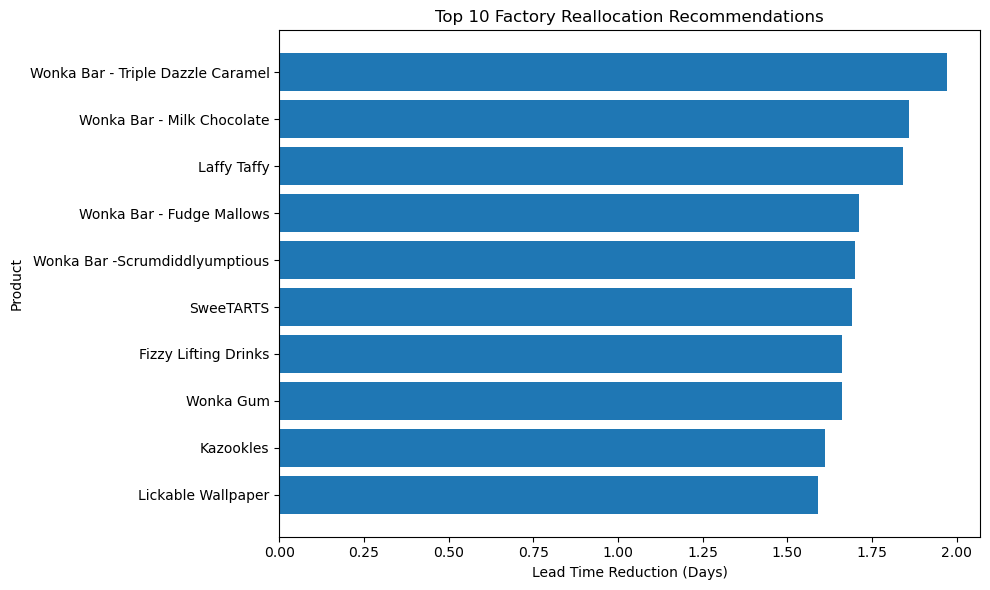

In [29]:
#Visualization
import matplotlib.pyplot as plt

top10 = recommendation_df.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top10["Product Name"],
    top10["Lead Time Reduction"],
)

plt.xlabel("Lead Time Reduction (Days)")
plt.ylabel("Product")
plt.title("Top 10 Factory Reallocation Recommendations")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [31]:
joblib.dump(distance_scaler, "distance_scaler.pkl")

['distance_scaler.pkl']